In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
file_path = '../data/Quote-Equity-ASIANPAINT-EQ-27-03-2025-27-03-2026.csv'
df = pd.read_csv(file_path)
df.head()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,27-Mar-2026,EQ,"2,246.30","2,269.00","2,201.10","2,270.20","2,209.20","2,207.40","2,225.52","2,985.70","2,115.00",1089010,"2,42,36,08,122.60",69114
1,25-Mar-2026,EQ,"2,225.10","2,289.70","2,222.00","2,217.30","2,271.00","2,270.20","2,264.27","2,985.70","2,115.00",1270855,"2,87,75,54,227.60",130505
2,24-Mar-2026,EQ,"2,184.00","2,224.50","2,153.30","2,121.30","2,220.50","2,217.30","2,196.94","2,985.70","2,115.00",1561016,"3,42,94,55,492.80",120036
3,23-Mar-2026,EQ,"2,180.00","2,180.00","2,115.00","2,195.40","2,120.80","2,121.30","2,138.30","2,985.70","2,115.00",978398,"2,09,21,08,841.10",84243
4,20-Mar-2026,EQ,"2,210.90","2,224.50","2,185.00","2,186.00","2,204.80","2,195.40","2,201.87","2,985.70","2,162.60",875920,"1,92,86,64,416.50",63193


In [22]:
df.columns = df.columns.str.strip()

# If Date is already the index from a previous run, bring it back as a column.
if 'Date' not in df.columns and df.index.name == 'Date':
    df = df.reset_index()

rename_map = {
    'DATE': 'Date',
    'OPEN': 'Open',
    'HIGH': 'High',
    'LOW': 'Low',
    'CLOSE': 'Close',
    'VOLUME': 'Shares Traded',
    'VALUE': 'Turnover (₹ Cr)'
}
df = df.rename(columns=rename_map)

required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}. Available columns: {df.columns.tolist()}")

df = df[required_cols].copy()

# Remove thousands separators and convert to numeric
for col in ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=False), errors='coerce')

# NSE VALUE is in rupees in raw CSV; convert once to crore rupees.
if df['Turnover (₹ Cr)'].median(skipna=True) > 1e6:
    df['Turnover (₹ Cr)'] = df['Turnover (₹ Cr)'] / 1e7

df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2026-03-27,2246.3,2269.0,2201.1,2207.4,1089010,242.360812
1,2026-03-25,2225.1,2289.7,2222.0,2270.2,1270855,287.755423
2,2026-03-24,2184.0,2224.5,2153.3,2217.3,1561016,342.945549
3,2026-03-23,2180.0,2180.0,2115.0,2121.3,978398,209.210884
4,2026-03-20,2210.9,2224.5,2185.0,2195.4,875920,192.866442


In [23]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             248 non-null    datetime64[ns]
 1   Open             248 non-null    float64       
 2   High             248 non-null    float64       
 3   Low              248 non-null    float64       
 4   Close            248 non-null    float64       
 5   Shares Traded    248 non-null    int64         
 6   Turnover (₹ Cr)  248 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.7 KB


Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

In [24]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df.set_index('Date', inplace=True)

In [25]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

# Visualize missing values if any exist
if missing_values.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.show()
else:
    print("\nNo missing values found in the dataset.")

Missing values per column:
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

Total missing values: 0

No missing values found in the dataset.


In [26]:
# Handle missing values if present
if df.isnull().sum().sum() > 0:
    df.ffill()
    df.bfill()

    print("Missing values handled using forward/backward fill.")
    print(f"Remaining missing values: {df.isnull().sum().sum()}")
else:
    print("No missing values to handle.")

No missing values to handle.


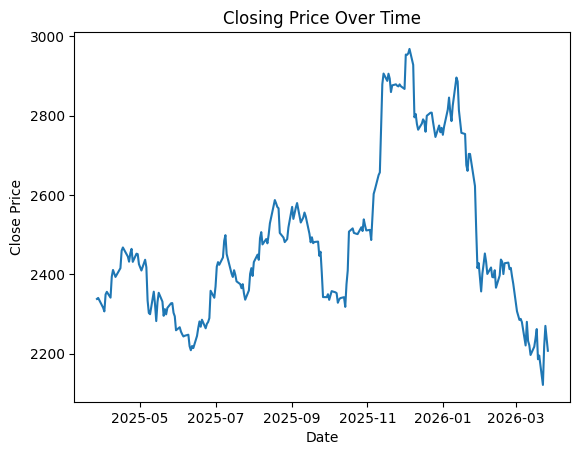

In [27]:
plt.figure()
plt.plot(df['Close'])
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

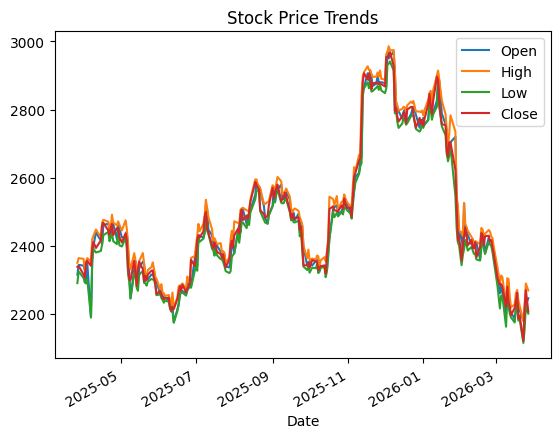

In [28]:
df[['Open','High','Low','Close']].plot()
plt.title('Stock Price Trends')
plt.show()

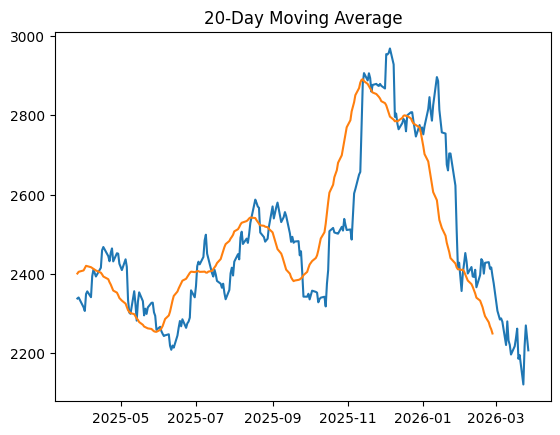

In [29]:
df['MA20'] = df['Close'].rolling(window=20).mean()

plt.figure()
plt.plot(df['Close'])
plt.plot(df['MA20'])
plt.title('20-Day Moving Average')
plt.show()

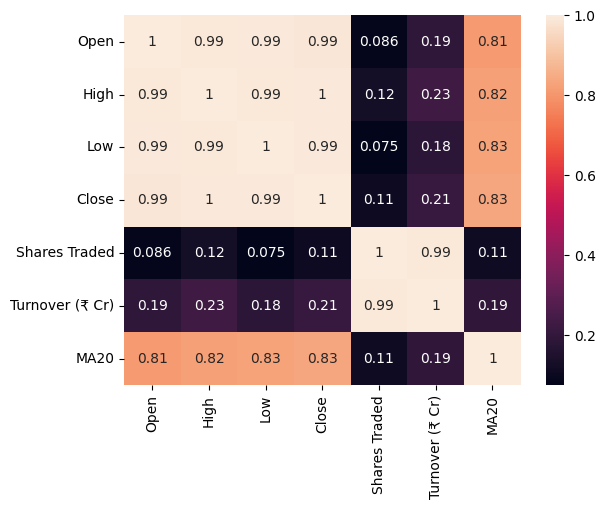

In [30]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.show()

In [31]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in numeric columns
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']
print("Outlier Detection (IQR Method):")
print("-" * 99)

for col in numeric_cols:
    if col in df.columns:
        outliers, lb, ub = detect_outliers_iqr(df, col)
        print(f"{col}: {len(outliers)} outliers (bounds: {lb:.2f} to {ub:.2f})")

Outlier Detection (IQR Method):
---------------------------------------------------------------------------------------------------
Open: 10 outliers (bounds: 2009.21 to 2891.71)
High: 14 outliers (bounds: 2035.42 to 2903.83)
Low: 12 outliers (bounds: 1994.88 to 2861.88)
Close: 5 outliers (bounds: 2000.69 to 2906.94)
Shares Traded: 19 outliers (bounds: -413109.12 to 2463893.88)
Turnover (₹ Cr): 16 outliers (bounds: -119.84 to 630.12)


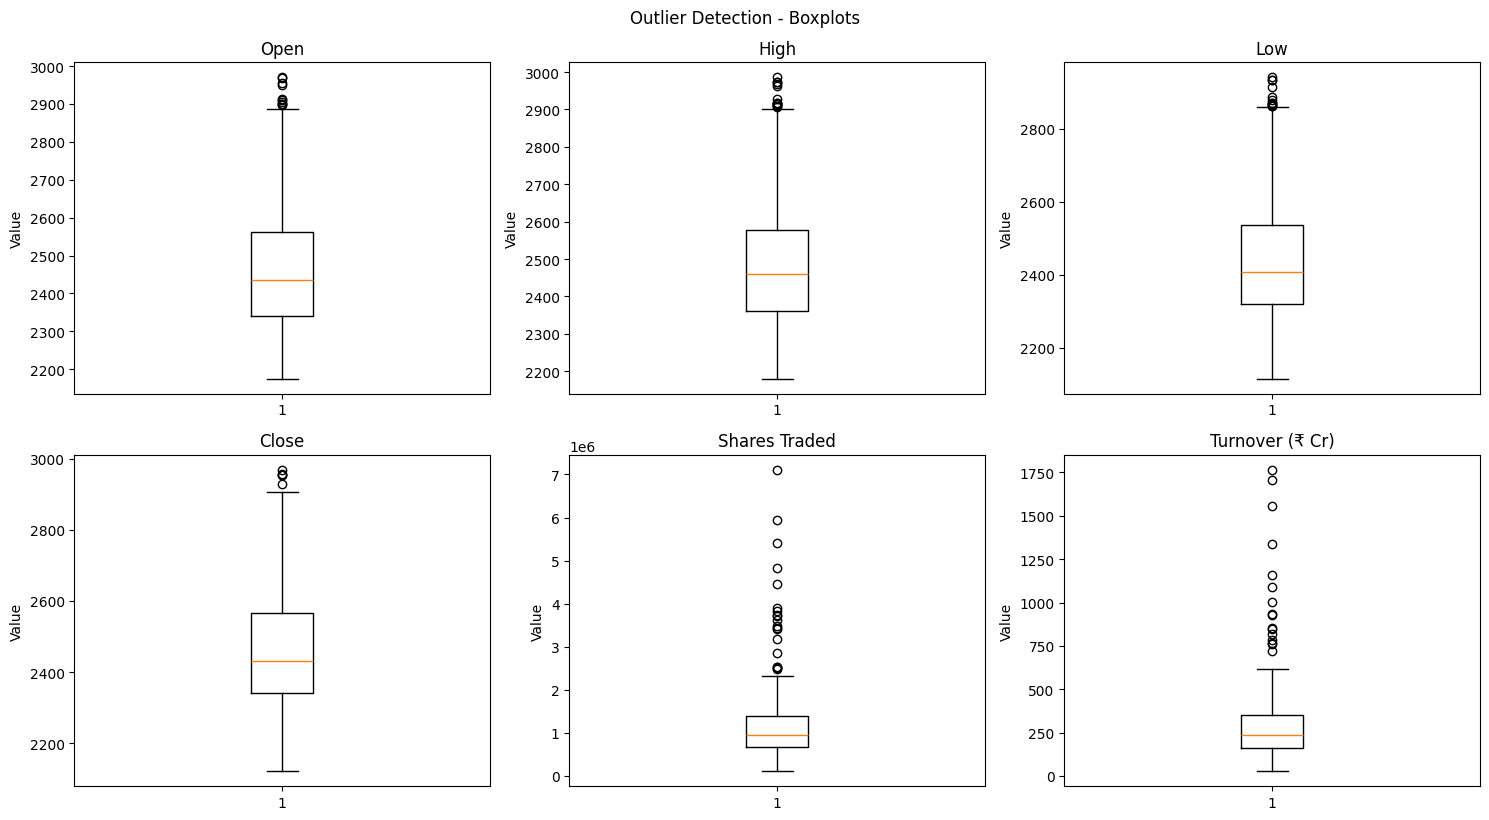

In [32]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']
for i, col in enumerate(numeric_cols):
    if col in df.columns:
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Value')

plt.tight_layout()
plt.suptitle('Outlier Detection - Boxplots', y=1.02)
plt.show()

In [33]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

volume_cols = ['Shares Traded', 'Turnover (₹ Cr)']
for col in volume_cols:
    if col in df.columns:
        df = cap_outliers(df.copy(), col)
        print(f"Outliers capped in: {col}")

print("\nPrice columns (Open, High, Low, Close) preserved to maintain market data integrity.")

Outliers capped in: Shares Traded
Outliers capped in: Turnover (₹ Cr)

Price columns (Open, High, Low, Close) preserved to maintain market data integrity.


In [34]:
# Regression Setup for RMSE and R² Evaluation
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
feature_cols = ['Open', 'High', 'Low', 'Close', 'MA20']
df['Next_Return'] = df['Close'].shift(-1) / df['Close'] - 1
df_reg = df.dropna()
X_reg = df_reg[feature_cols]
y_reg = df_reg['Next_Return']
split_idx_reg = int(len(X_reg) * 0.8)
X_train_reg, X_test_reg = X_reg[:split_idx_reg], X_reg[split_idx_reg:]
y_train_reg, y_test_reg = y_reg[:split_idx_reg], y_reg[split_idx_reg:]

# Scaling....
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

print(f"Regression data ready: {len(X_train_reg)} train, {len(X_test_reg)} test samples")

Regression data ready: 182 train, 46 test samples


In [35]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train_scaled, y_train_reg)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
print("\n--- Model Performance Summary ---")
for name, metrics in results.items():
    print(f"{name}: MSE = {metrics['MSE']:.4f}, R2 = {metrics['R2']:.4f}")


--- Linear Regression ---
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.1263

--- Ridge Regression ---
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.3258

--- Random Forest Regressor ---
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.4023

--- Gradient Boosting Regressor ---
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.4425

--- Model Performance Summary ---
Linear Regression: MSE = 0.0001, R2 = 0.1263
Ridge Regression: MSE = 0.0001, R2 = 0.3258
Random Forest Regressor: MSE = 0.0001, R2 = 0.4023
Gradient Boosting Regressor: MSE = 0.0001, R2 = 0.4425


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_reg)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate the model
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
r2_linear = r2_score(y_test_reg, y_pred_linear)

print("--- Simple Linear Regression Model ---")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"R-squared (R²): {r2_linear:.4f}")

--- Simple Linear Regression Model ---
Mean Squared Error (MSE): 0.0001
R-squared (R²): 0.1263


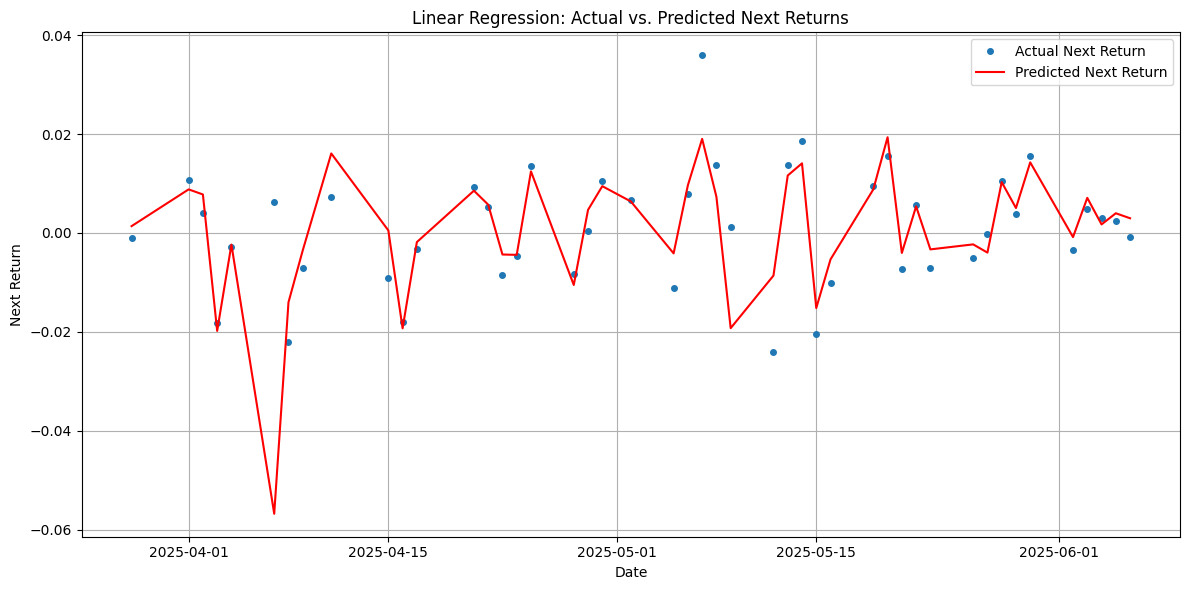

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_reg.index, y_test_reg, label='Actual Next Return', marker='o', linestyle='None', markersize=4)
plt.plot(y_test_reg.index, y_pred_linear, label='Predicted Next Return', linestyle='-', color='red')
plt.title('Linear Regression: Actual vs. Predicted Next Returns')
plt.xlabel('Date')
plt.ylabel('Next Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import accuracy_score

# Convert continuous predictions to direction classification (1 = up, 0 = down)
y_test_direction = (y_test_reg > 0).astype(int)
y_pred_direction = (y_pred_linear > 0).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test_direction, y_pred_direction)
print(f"Direction Prediction Accuracy: {accuracy:.4f}")

Direction Prediction Accuracy: 0.8913


In [40]:
# LSTM Model for Time Series Prediction
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Prepare sequences for LSTM (lookback = 10 timesteps)
def create_sequences(X, y, lookback=10):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y.iloc[i])
    return np.array(X_seq), np.array(y_seq)

lookback = 10
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_reg, lookback)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test_reg, lookback)

print(f"LSTM Training data shape: {X_train_lstm.shape}")
print(f"LSTM Test data shape: {X_test_lstm.shape}")

# Build LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(lookback, X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Train the LSTM model
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Make predictions
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Evaluate regression metrics
mse_lstm = mean_squared_error(y_test_lstm, y_pred_lstm)
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

# Direction accuracy
y_test_dir_lstm = (y_test_lstm > 0).astype(int)
y_pred_dir_lstm = (y_pred_lstm > 0).astype(int)
accuracy_lstm = accuracy_score(y_test_dir_lstm, y_pred_dir_lstm)

print("\n--- LSTM Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_lstm:.6f}")
print(f"R-squared (R²): {r2_lstm:.4f}")
print(f"Direction Prediction Accuracy: {accuracy_lstm:.4f}")

LSTM Training data shape: (172, 10, 5)
LSTM Test data shape: (36, 10, 5)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,701 (127.74 KB)

 Trainable params: 32,701 (127.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0115 - val_loss: 0.0019
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0034 - val_loss: 0.0044
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0034 - val_loss: 8.1430e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014 - val_loss: 1.9593e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7.9766e-04 - val_loss: 0.0013
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.5906e-04 - val_loss: 6.1862e-04
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.4839e-04 - val_loss: 1.6225e-04
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5.7017e-04 - val_loss: 1.4494e-04
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4.9803e-04 - val_loss: 6.3254e-04
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6.5706e-04 - val_loss: 3.4626e-04
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━

In [41]:
# Save the LSTM model
import os
import joblib

# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the Keras LSTM model
lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print(f"LSTM model saved to {models_dir}/lstm_model.keras")

# Save the scaler for preprocessing new data
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
print(f"Scaler saved to {models_dir}/scaler.pkl")

# Save model configuration for reference
model_config = {
    'lookback': lookback,
    'feature_cols': feature_cols,
    'mse': mse_lstm,
    'r2': r2_lstm,
    'accuracy': accuracy_lstm
}
joblib.dump(model_config, os.path.join(models_dir, 'model_config.pkl'))
print(f"Model config saved to {models_dir}/model_config.pkl")

LSTM model saved to ../models/lstm_model.keras
Scaler saved to ../models/scaler.pkl
Model config saved to ../models/model_config.pkl
